In [2]:
#IMPORTAÇÕES
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

from statsmodels.graphics.tsaplots import plot_acf,plot_pacf 
from statsmodels.tsa.seasonal import seasonal_decompose

# Lendo os dados
df = pd.read_excel(
    "~/IC-Gasto-Fotovoltaico-main/Controle_Faturamento_2023.xlsx",
    sheet_name="Consumo Médio - Clientes",
)

# Removendo dados desnecessários
df.drop(df.iloc[:, 48:68], inplace=True, axis=1)
df.drop("Nº Cliente", inplace=True, axis=1)
df.drop("Cliente", inplace=True, axis=1)

df = df.head()

# Corrigindo os dados para uso das fórmulas (Colocando a data como índice do dataset)
df = df.transpose()
df = df.rename(columns=df.iloc[0])
df.drop("UC", inplace=True, axis=0)
df.dropna(inplace=True)

# transformando índice em datetime
df.index
some_dates = np.array(df.index, dtype="datetime64[D]")
idx = pd.DatetimeIndex(some_dates)
df["idx"] = idx
df.set_index("idx", inplace=True)

#Ajustando a frequencia do indice para "MS" (Month Start)
df.index.freq = "MS"
df.head()

,3003858507,3001084033,3011373971,3001449459,3011504476
idx,,,,,
2019-06-01,1246.0,7160.0,440.0,960.0,1560.0
2019-07-01,1081.0,6520.0,600.0,920.0,1280.0
2019-08-01,1184.0,6840.0,680.0,1120.0,1360.0
2019-09-01,1549.0,7440.0,760.0,1040.0,1680.0
2019-10-01,2045.0,6920.0,560.0,1120.0,1680.0


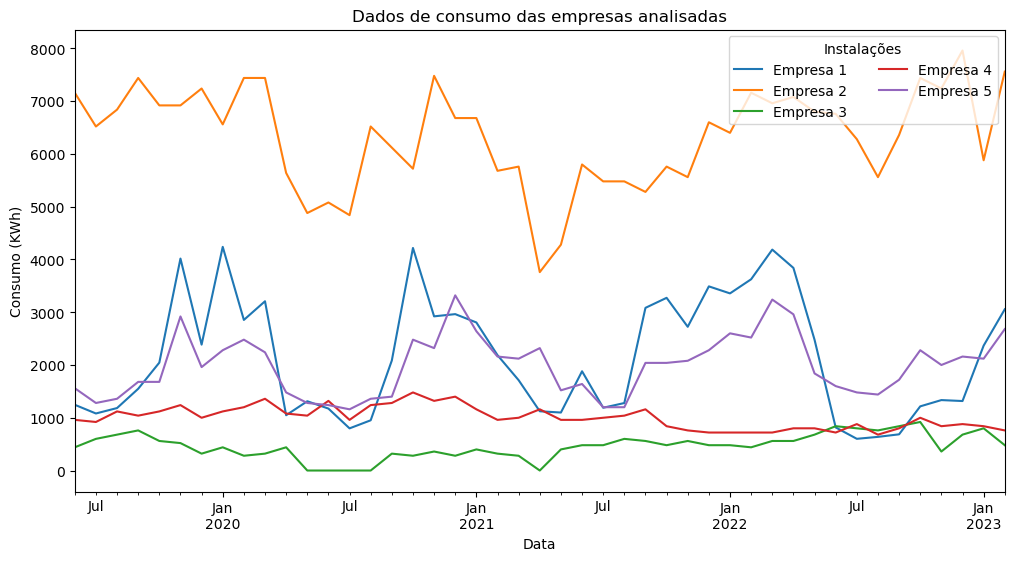

In [14]:
title = "Dados de consumo das empresas analisadas"
ylabel = "Consumo (KWh)"
xlabel = "Data"

ax = df[3003858507].plot(label="Empresa 1 ")
df[3001084033].plot(figsize=(12, 6), title=title,label="Empresa 2")
df[3011373971].plot(label="Empresa 3")
df[3001449459].plot(label="Empresa 4")
df[3011504476].plot(label="Empresa 5")
plt.legend(title="Instalações",ncols=2,fancybox=True, loc="upper right")
ax.autoscale(axis="x", tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)
plt.savefig("comp_graph.png")


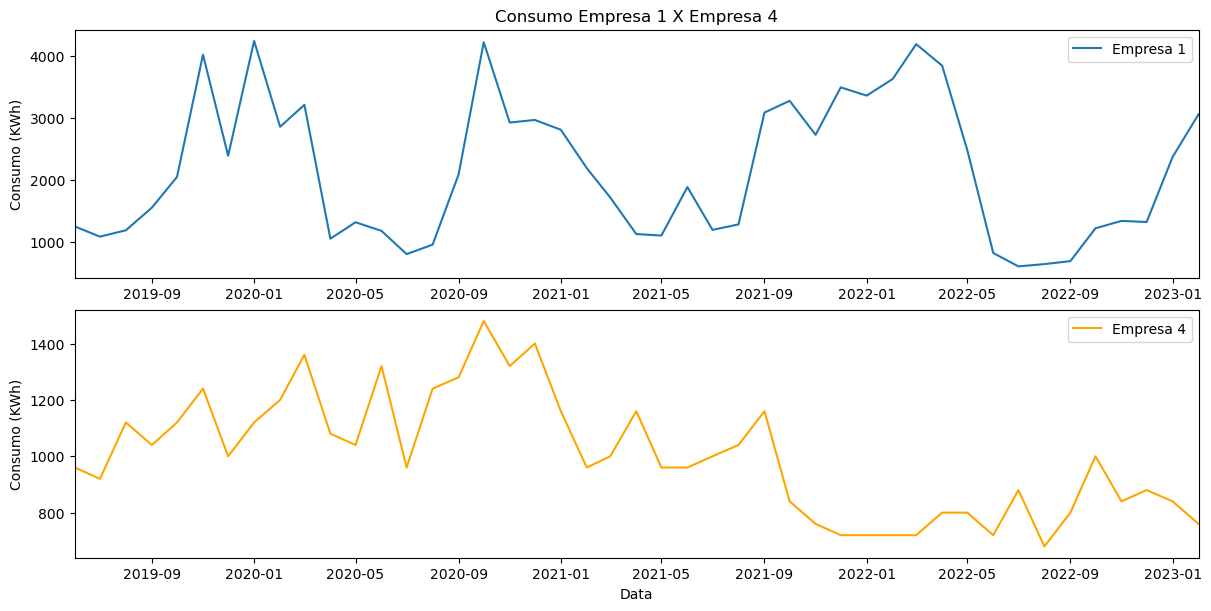

In [18]:
title = "Consumo Empresa 1 X Empresa 4"
ylabel = "Consumo (KWh)"
xlabel = "Data"
fig, (ax1, ax2) = plt.subplots(2, 1, layout='constrained',figsize=(12,6))
#ax1 = df[3001449459].plot(label="MD Predial - 1")
#ax2 = df[3011504476].plot(label="MD Predial - 2")
ax1.plot(df[3003858507].index,df[3003858507],label="Empresa 1")
ax1.set(ylabel=ylabel,title=title)
ax1.legend(loc="upper right")
ax1.autoscale(axis="x", tight=True)
ax2.plot(df[3001449459].index,df[3001449459],label="Empresa 4",color='orange')
ax2.set(xlabel=xlabel, ylabel=ylabel)
ax2.legend(loc="upper right")
ax2.autoscale(axis="x", tight=True)

plt.savefig("md_pred_lucile_comp_graph.png")

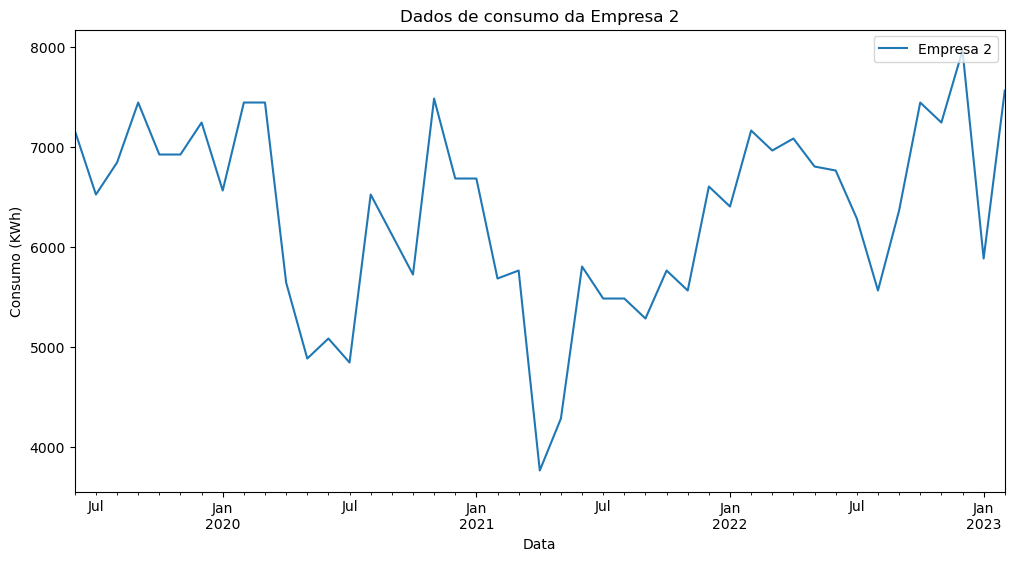

In [17]:
title = "Dados de consumo da Empresa 2"
ylabel = "Consumo (KWh)"
xlabel = "Data"

ax = df[3001084033].plot(label="Empresa 2",figsize=(12, 6),title=title)
plt.legend(loc="upper right")
ax.autoscale(axis="x", tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)
plt.savefig("empr2.png")

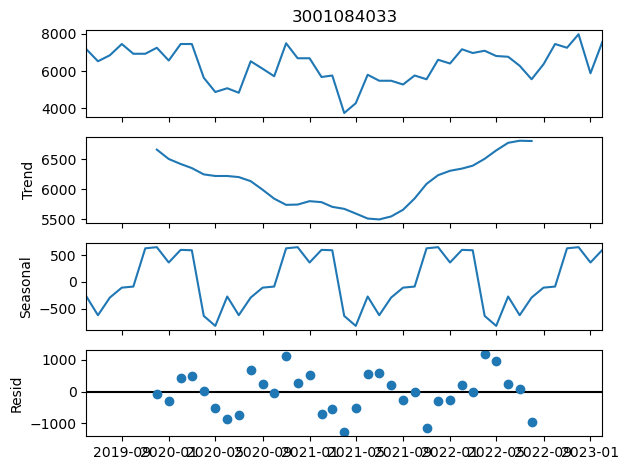

In [14]:
seasonal_decompose(df[3001084033]).plot();